# Install/import libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import plotly.express as px

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Task 0 — Load pretrained ResNet-18

In [3]:
# Load pretrained ResNet-18 trained on ImageNet
resnet18 = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Move model to device
resnet18 = resnet18.to(device)

# Set model to evaluation mode
resnet18.eval()

print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

We load a ResNet-18 model pretrained on ImageNet and set it to evaluation mode using `.eval()`. This model will not be trained in this notebook. Instead, it will be used as a fixed feature extractor to obtain 512-dimensional embeddings from the CIFAR-10 test images.

#Task 1 — Load CIFAR-10 test set with ResNet preprocessing

In [4]:
# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [5]:
# Preprocessing required for ResNet-18 compatibility
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# Load CIFAR-10 test set only
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=resnet_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2
)

print("Number of test images:", len(test_dataset))

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Number of test images: 10000


In [7]:
images, labels = next(iter(test_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([256, 3, 224, 224])
Labels shape: torch.Size([256])


CIFAR-10 images are originally 32×32 pixels, but ResNet-18 expects 224×224 RGB images. Therefore, we resize each image to 224×224, convert it to a PyTorch tensor, and normalize it using the ImageNet mean and standard deviation because the pretrained ResNet-18 was trained on ImageNet.

# Task 2 — Extract 512-dimensional embeddings using forward hook on avgpool

In [8]:
# Storage for embeddings and labels
all_embeddings = []
all_labels = []

In [9]:
# This hook function saves the output of avgpool
def avgpool_hook(module, input, output):
    # output shape: [batch_size, 512, 1, 1]
    embeddings = output.squeeze(-1).squeeze(-1)  # shape: [batch_size, 512]
    all_embeddings.append(embeddings.detach().cpu())

In [10]:
# Register hook on avgpool layer
hook_handle = resnet18.avgpool.register_forward_hook(avgpool_hook)

In [11]:
# Run the full CIFAR-10 test set through ResNet-18
resnet18.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Forward pass triggers the hook
        _ = resnet18(images)

        all_labels.append(labels.cpu())

In [12]:
# Remove hook after extraction
hook_handle.remove()

In [13]:
# Combine all batches into one tensor / array
embeddings_tensor = torch.cat(all_embeddings, dim=0)
labels_tensor = torch.cat(all_labels, dim=0)

embeddings = embeddings_tensor.numpy()
labels = labels_tensor.numpy()

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Embeddings shape: (10000, 512)
Labels shape: (10000,)


We register a forward hook on the `avgpool` layer of ResNet-18. This layer is located just before the final classification layer and produces a 512-dimensional feature vector for each image. These embeddings represent how the pretrained ImageNet model internally describes each CIFAR-10 image.

#Task 3 — PCA and t-SNE to 2D

### PCA 2D

In [14]:
pca_2d = PCA(n_components=2, random_state=42)

embeddings_pca_2d = pca_2d.fit_transform(embeddings)

print("PCA 2D shape:", embeddings_pca_2d.shape)
print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
print("Total explained variance:", pca_2d.explained_variance_ratio_.sum())

PCA 2D shape: (10000, 2)
Explained variance ratio: [0.10749035 0.05058045]
Total explained variance: 0.1580708


### t-SNE 2D

In [15]:
tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

embeddings_tsne_2d = tsne_2d.fit_transform(embeddings)

print("t-SNE 2D shape:", embeddings_tsne_2d.shape)

t-SNE 2D shape: (10000, 2)


### Plot PCA and t-SNE side by side

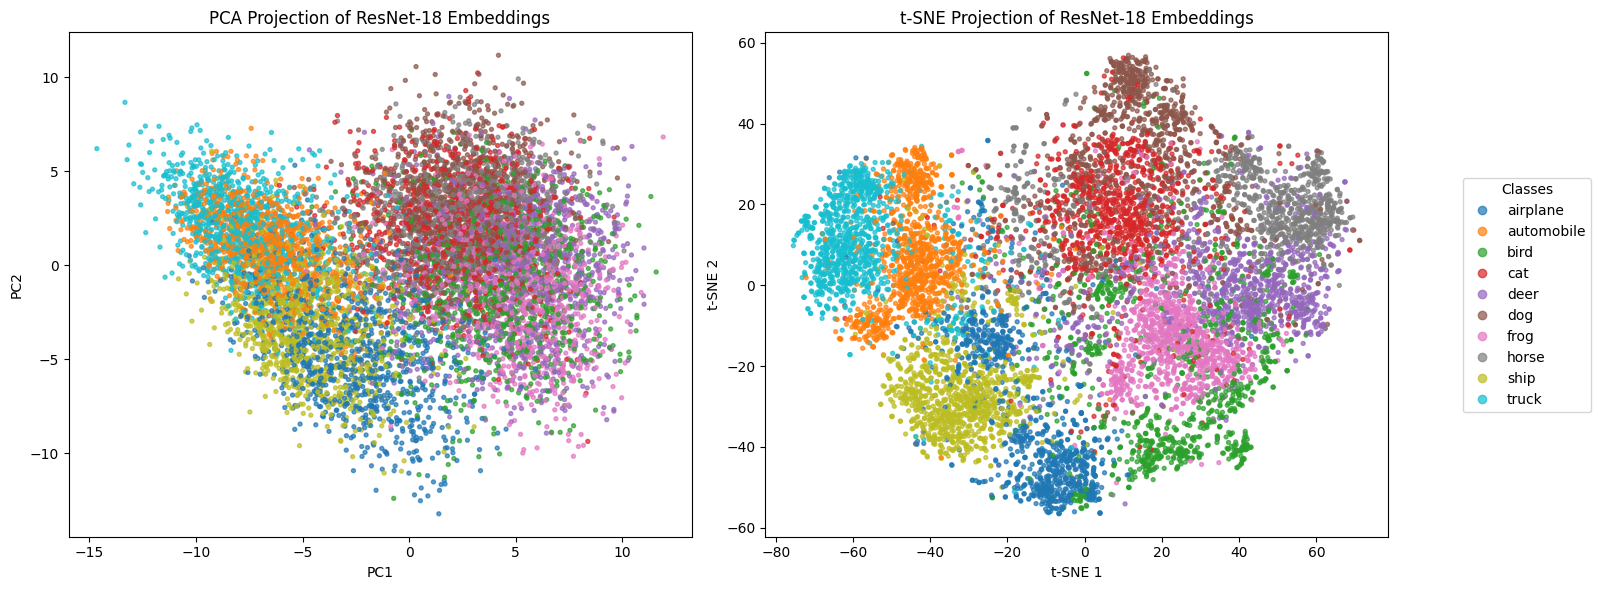

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
scatter1 = axes[0].scatter(
    embeddings_pca_2d[:, 0],
    embeddings_pca_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

axes[0].set_title("PCA Projection of ResNet-18 Embeddings")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# t-SNE plot
scatter2 = axes[1].scatter(
    embeddings_tsne_2d[:, 0],
    embeddings_tsne_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=8,
    alpha=0.7
)

axes[1].set_title("t-SNE Projection of ResNet-18 Embeddings")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

# Shared legend
handles, _ = scatter2.legend_elements()
fig.legend(
    handles,
    class_names,
    title="Classes",
    loc="center right"
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

The PCA plot shows the broad global structure of the ResNet-18 embeddings. Since PCA is linear, it may show partial class separation but usually has substantial overlap between classes.

The t-SNE plot often shows clearer local clusters because it is nonlinear and focuses on preserving neighborhood relationships. If some CIFAR-10 classes form visible clusters, this suggests that the pretrained ImageNet ResNet-18 has learned transferable visual representations, even though it was not specifically trained on CIFAR-10.

However, the clusters may not be perfectly separated. This is expected because CIFAR-10 images are small 32×32 images upscaled to 224×224, while ResNet-18 was pretrained on higher-resolution ImageNet photographs. Therefore, the representation is useful but not perfectly adapted to CIFAR-10.

# Task 4 — 3D t-SNE interactive plot

In [17]:
tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

embeddings_tsne_3d = tsne_3d.fit_transform(embeddings)

print("t-SNE 3D shape:", embeddings_tsne_3d.shape)

t-SNE 3D shape: (10000, 3)


In [18]:
tsne_3d_df = pd.DataFrame({
    "tsne_1": embeddings_tsne_3d[:, 0],
    "tsne_2": embeddings_tsne_3d[:, 1],
    "tsne_3": embeddings_tsne_3d[:, 2],
    "label": labels,
    "class_name": [class_names[i] for i in labels]
})

tsne_3d_df.head()

,tsne_1,tsne_2,tsne_3,label,class_name
0,6.336430,3.344287,-12.662876,3,cat
1,-23.621277,-15.179361,7.433214,8,ship
2,-26.534693,-11.716465,10.252585,8,ship
3,-21.979612,10.674936,25.468834,0,airplane
4,22.519701,-14.647309,16.233475,6,frog


### Interactive 3D plot:

In [19]:
fig = px.scatter_3d(
    tsne_3d_df,
    x="tsne_1",
    y="tsne_2",
    z="tsne_3",
    color="class_name",
    opacity=0.7,
    title="3D t-SNE of CIFAR-10 Test Embeddings from Pretrained ResNet-18",
    width=900,
    height=700
)

fig.update_traces(marker=dict(size=3))
fig.show()

The 3D t-SNE visualization allows us to inspect the local structure of the feature space more flexibly by rotating the plot. If points from the same CIFAR-10 class appear close together, this indicates that the pretrained ResNet-18 embeddings contain class-relevant information.

Some classes may form stronger clusters than others. For example, visually distinctive classes such as ships, airplanes, trucks, or automobiles may separate better than visually similar animal classes such as cats, dogs, and deer. This suggests that ImageNet pretraining provides useful general-purpose representations, but these representations are not perfectly optimized for CIFAR-10 without task-specific fine-tuning.